# FER Dataset — General Report

General exploratory analysis of the `fer_data/` folder:
per-class image counts, dimensions, channels, file extensions,
and a sample grid of one image per class.

In [1]:
import os
from pathlib import Path
from collections import Counter

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path("fer_data")
EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

rows = []
for class_dir in sorted(DATA_DIR.iterdir()):
    if not class_dir.is_dir():
        continue
    files = [p for p in class_dir.iterdir() if p.is_file() and p.suffix.lower() in EXTS]
    ext_counts = Counter(p.suffix.lower() for p in files)
    rows.append({
        "class": class_dir.name,
        "n_images": len(files),
        ".jpg": ext_counts.get(".jpg", 0),
        ".jpeg": ext_counts.get(".jpeg", 0),
        ".png": ext_counts.get(".png", 0),
        ".bmp": ext_counts.get(".bmp", 0),
        ".webp": ext_counts.get(".webp", 0),
    })

df = pd.DataFrame(rows)
df["share_%"] = (df["n_images"] / df["n_images"].sum() * 100).round(2)
df

,class,n_images,.jpg,.jpeg,.png,.bmp,.webp,share_%
0,angry😡,152,148,1,3,0,0,12.30
1,fear😟,135,125,1,9,0,0,10.92
2,happy😃,276,273,1,2,0,0,22.33
3,normal🙂,277,275,2,0,0,0,22.41
4,sad😥,221,213,2,6,0,0,17.88
5,surprise😮,175,173,2,0,0,0,14.16


In [2]:
# Sample-based stats: read a small subset per class for shape/channel/mean stats
SAMPLE_PER_CLASS = 25

def class_samples(class_dir, k=SAMPLE_PER_CLASS):
    files = sorted(p for p in class_dir.iterdir()
                   if p.is_file() and p.suffix.lower() in EXTS)
    return files[:k]

stats = []
for class_dir in sorted(DATA_DIR.iterdir()):
    if not class_dir.is_dir():
        continue
    sample_files = class_samples(class_dir)
    shapes, channels, means = [], [], []
    for fp in sample_files:
        img = cv2.imread(str(fp))
        if img is None:
            continue
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img_rgb.shape[:2]
        c = 1 if img_rgb.ndim == 2 else img_rgb.shape[2]
        shapes.append((h, w))
        channels.append(c)
        means.append(img_rgb.mean())
    if not shapes:
        continue
    hs = [s[0] for s in shapes]; ws = [s[1] for s in shapes]
    stats.append({
        "class": class_dir.name,
        "sampled": len(sample_files),
        "min_HxW": f"{min(hs)}x{min(ws)}",
        "max_HxW": f"{max(hs)}x{max(ws)}",
        "mean_HxW": f"{int(np.mean(hs))}x{int(np.mean(ws))}",
        "channels_mode": Counter(channels).most_common(1)[0][0],
        "pixel_mean": round(float(np.mean(means)), 2),
    })

pd.DataFrame(stats)

,class,sampled,min_HxW,max_HxW,mean_HxW,channels_mode,pixel_mean
0,angry😡,25,352x260,2932x2932,1022x809,3,120.31
1,fear😟,25,312x220,2160x1582,992x680,3,113.74
2,happy😃,25,441x311,2436x2436,1172x967,3,118.21
3,normal🙂,25,316x248,1696x1696,840x678,3,119.92
4,sad😥,25,188x130,3048x3048,1042x893,3,124.38
5,surprise😮,25,380x252,3048x3048,1113x899,3,116.93


/tmp/ipykernel_160452/1517765785.py:7: UserWarning: Glyph 128578 (\N{SLIGHTLY SMILING FACE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/lost/XD/AI/fer/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128578 (\N{SLIGHTLY SMILING FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


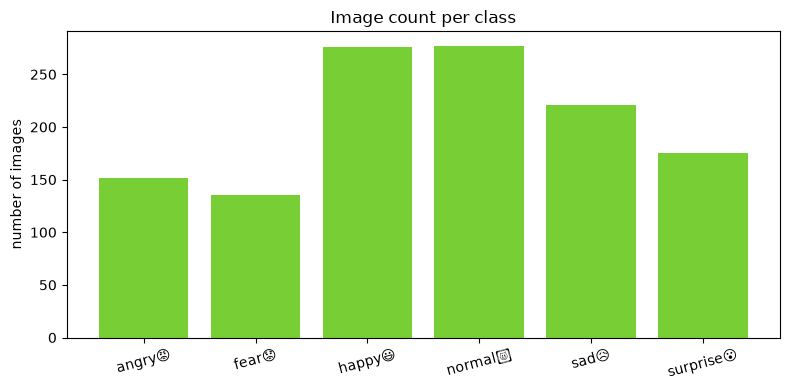

Total images: 1236
Number of classes: 6
Imbalance ratio (max/min): 2.05


In [3]:
# Distribution plot: class counts
plt.figure(figsize=(8, 4))
plt.bar(df["class"], df["n_images"], color="#77CE35")
plt.title("Image count per class")
plt.ylabel("number of images")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

print(f"Total images: {df['n_images'].sum()}")
print(f"Number of classes: {len(df)}")
print(f"Imbalance ratio (max/min): "
      f"{df['n_images'].max() / max(df['n_images'].min(), 1):.2f}")

/tmp/ipykernel_160452/2869244981.py:14: UserWarning: Glyph 128578 (\N{SLIGHTLY SMILING FACE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


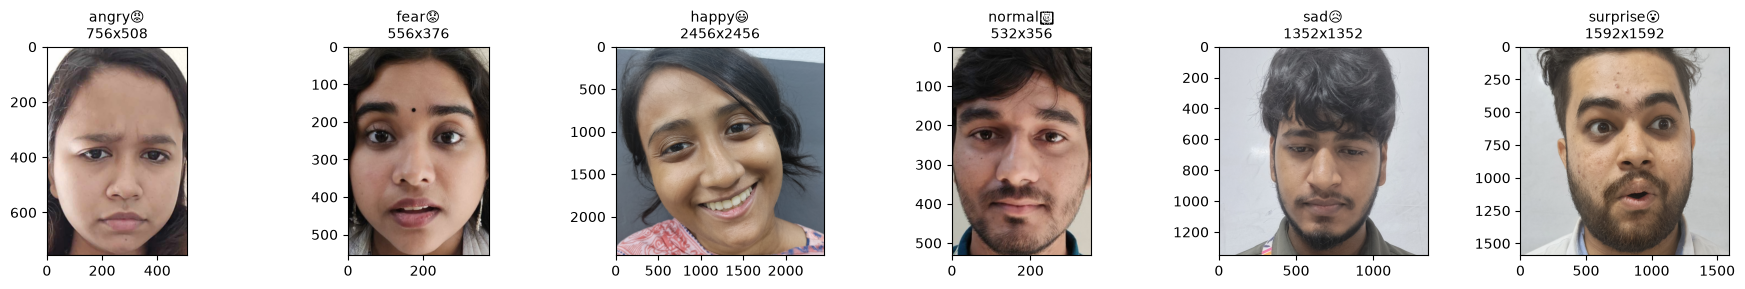

In [4]:
# Sample grid: one image per class
classes = sorted(d for d in DATA_DIR.iterdir() if d.is_dir())
fig, axes = plt.subplots(1, len(classes), figsize=(3 * len(classes), 3))
if len(classes) == 1:
    axes = [axes]
for ax, cls in zip(axes, classes):
    files = sorted(p for p in cls.iterdir()
                   if p.is_file() and p.suffix.lower() in EXTS)
    img = cv2.imread(str(files[34]))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(f"{cls.name}\n{img.shape[0]}x{img.shape[1]}", fontsize=10)
    ax.axis("on")
plt.tight_layout()
plt.show()